# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [1]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

169001437/169001437 [==============================] - 15s 0us/step


In [2]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

Training set shape: (50000, 32, 32, 3), Labels: (50000, 1)
Test set shape: (10000, 32, 32, 3), Labels: (10000, 1)


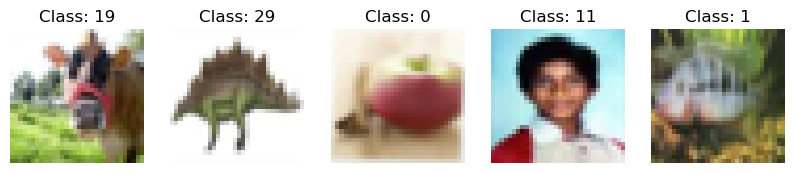

In [3]:
# Your Code Here
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Print dataset shapes
print(f"Training set shape: {x_train.shape}, Labels: {y_train.shape}")
print(f"Test set shape: {x_test.shape}, Labels: {y_test.shape}")

# Display some images with their labels
fig, axes = plt.subplots(1, 5, figsize=(10, 5))
for i in range(5):
    axes[i].imshow(x_train[i])
    axes[i].set_title(f"Class: {y_train[i][0]}")
    axes[i].axis("off")
plt.show()


### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [4]:
# Your Code Here
# Normalize images to range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

# Split training set into training (80%) and validation (20%)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Print final dataset shapes
print(f"Final training set: {x_train.shape}, Validation set: {x_val.shape}, Test set: {x_test.shape}")


Final training set: (40000, 32, 32, 3), Validation set: (10000, 32, 32, 3), Test set: (10000, 32, 32, 3)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [5]:
# Your Code Here
# Define the CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(100, activation='softmax')  # 100 classes
])

# Print model summary
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dense (Dense)               (None, 128)               2

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- Loss function: categorical_crossentropy is used because labels are multi-class classification (labels are one-hot encoded), and measures how far the predicted probability distribution is from the actual class. It also works well when using 'softmax' activation.
- Optimizer: 'adam' is used because it combines the benefits of momentum-based optimization and helps with convergence, and adaptive learning rates methods and adjusts learning rates methods individually for each parameter.

In [6]:
# Your Code Here
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [7]:
# Your Code Here
# Train the model
history = model.fit(x_train, y_train, epochs=20, batch_size=32,
                    validation_split=0.2, verbose=1)


Epoch 1/20
1000/1000 [==============================] - 35s 33ms/step - loss: 3.8973 - accuracy: 0.1098 - val_loss: 3.4624 - val_accuracy: 0.1824
Epoch 2/20
1000/1000 [==============================] - 33s 33ms/step - loss: 3.1812 - accuracy: 0.2330 - val_loss: 3.0742 - val_accuracy: 0.2488
Epoch 3/20
1000/1000 [==============================] - 34s 34ms/step - loss: 2.8282 - accuracy: 0.2994 - val_loss: 2.8881 - val_accuracy: 0.2901
Epoch 4/20
1000/1000 [==============================] - 35s 35ms/step - loss: 2.5761 - accuracy: 0.3500 - val_loss: 2.8269 - val_accuracy: 0.3086
Epoch 5/20
1000/1000 [==============================] - 35s 35ms/step - loss: 2.3913 - accuracy: 0.3861 - val_loss: 2.7281 - val_accuracy: 0.3251
Epoch 6/20
1000/1000 [==============================] - 34s 34ms/step - loss: 2.2376 - accuracy: 0.4205 - val_loss: 2.7285 - val_accuracy: 0.3311
Epoch 7/20
1000/1000 [==============================] - 34s 34ms/step - loss: 2.1068 - accuracy: 0.4490 - val_loss: 2.7852 -

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [8]:
# Your Code Here
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc:.4f}")


313/313 - 4s - loss: 4.1428 - accuracy: 0.3107 - 4s/epoch - 11ms/step
Test Accuracy: 0.3107


### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

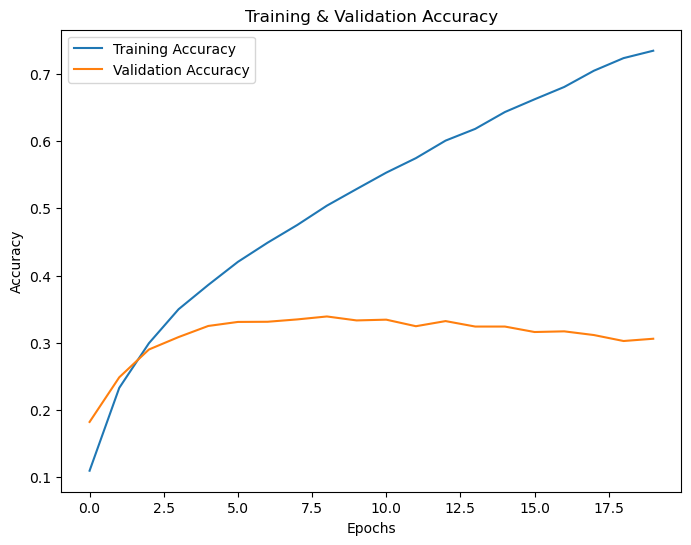

313/313 [==============================] - 5s 13ms/step


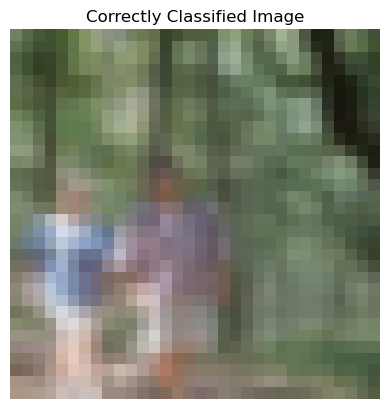

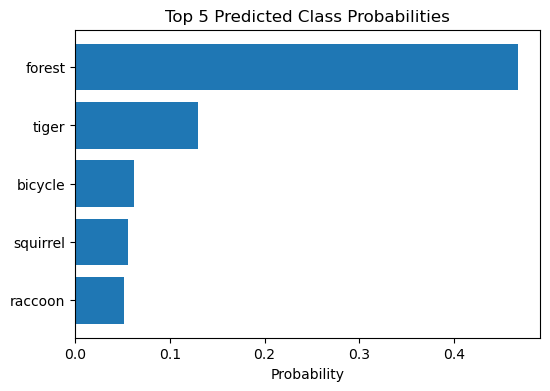

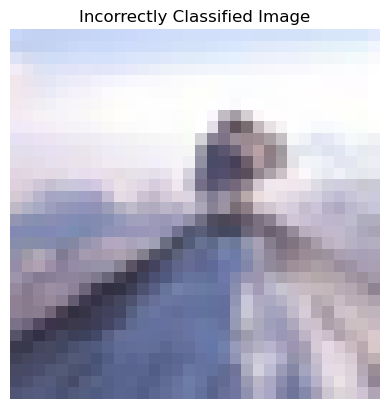

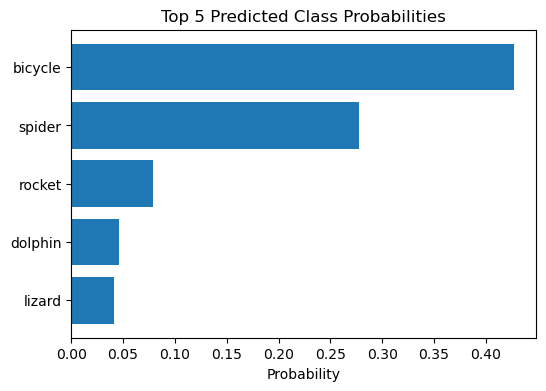

In [9]:
# Your Code Here

# Plot training & validation accuracy over epochs
def plot_training_history(history):
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training & Validation Accuracy')
    plt.show()

# Call the function to visualize model learning
plot_training_history(history)  # Assuming 'history' is from model.fit()

# Make predictions on test data
predictions = model.predict(x_test)

# Convert predictions from probability to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Find a correctly classified image
correct_idx = np.where(predicted_labels == true_labels)[0][0]
incorrect_idx = np.where(predicted_labels != true_labels)[0][0]

# Function to plot an image and its predicted probabilities
def plot_prediction(idx, title):
    plt.imshow(x_test[idx])
    plt.title(title)
    plt.axis('off')
    plt.show()
    
    # Display the top 5 class probabilities
    top_5_idx = np.argsort(predictions[idx])[-5:][::-1]  # Get top 5 predictions
    top_5_probs = predictions[idx][top_5_idx]
    top_5_labels = [class_names[i] for i in top_5_idx]
    
    # Plot probabilities
    plt.figure(figsize=(6, 4))
    plt.barh(top_5_labels[::-1], top_5_probs[::-1])
    plt.xlabel('Probability')
    plt.title('Top 5 Predicted Class Probabilities')
    plt.show()

# Plot correctly classified image
plot_prediction(correct_idx, "Correctly Classified Image")

# Plot incorrectly classified image
plot_prediction(incorrect_idx, "Incorrectly Classified Image")


## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [10]:
# Your Code Here
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Apply Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,       # Rotate images by 15 degrees
    width_shift_range=0.1,   # Shift width by 10%
    height_shift_range=0.1,  # Shift height by 10%
    horizontal_flip=True,    # Flip images horizontally
    zoom_range=0.1           # Random zoom
)
datagen.fit(x_train)

# Define an improved CNN model with Batch Normalization
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),  # Normalize activations
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Reduces overfitting
    Dense(100, activation='softmax')  # CIFAR-100 has 100 classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train using data augmentation
history = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                    validation_data=(x_val, y_val),
                    epochs=50)  # You can tune the number of epochs


Epoch 1/50
1250/1250 [==============================] - 378s 301ms/step - loss: 4.5281 - accuracy: 0.0245 - val_loss: 4.3188 - val_accuracy: 0.0407
Epoch 2/50
1250/1250 [==============================] - 283s 226ms/step - loss: 4.3632 - accuracy: 0.0331 - val_loss: 4.2806 - val_accuracy: 0.0443
Epoch 3/50
1250/1250 [==============================] - 275s 220ms/step - loss: 4.3033 - accuracy: 0.0374 - val_loss: 4.1160 - val_accuracy: 0.0505
Epoch 4/50
1250/1250 [==============================] - 327s 261ms/step - loss: 4.2486 - accuracy: 0.0417 - val_loss: 3.9737 - val_accuracy: 0.0788
Epoch 5/50
1250/1250 [==============================] - 335s 268ms/step - loss: 4.2061 - accuracy: 0.0471 - val_loss: 3.9813 - val_accuracy: 0.0783
Epoch 6/50
1250/1250 [==============================] - 322s 257ms/step - loss: 4.1553 - accuracy: 0.0524 - val_loss: 3.8789 - val_accuracy: 0.0970
Epoch 7/50
1250/1250 [==============================] - 327s 261ms/step - loss: 4.0858 - accuracy: 0.0654 - val_

Explanation of the Enhancements
Data Augmentation:
Prevents overfitting by creating slightly altered versions of training images.
Helps the model generalize better to unseen images.

Batch Normalization:
Normalizes intermediate activations, leading to more stable training.
Helps mitigate vanishing/exploding gradients.
Leads to faster convergence.
Dropout (0.5) in Dense Layer:
Reduces overfitting by randomly turning off neurons during training.

Why These Techniques?
CIFAR-100 has many classes with limited data per class, so augmentation helps expand the dataset.
Batch Normalization helps avoid internal covariate shift, stabilizing training.
Dropout prevents overfitting and improves generalization.

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

Epoch 1/50
1250/1250 [==============================] - 499s 398ms/step - loss: 1.5480 - accuracy: 0.5668 - val_loss: 1.8647 - val_accuracy: 0.5378
Epoch 2/50
1250/1250 [==============================] - 358s 286ms/step - loss: 1.5254 - accuracy: 0.5699 - val_loss: 1.7927 - val_accuracy: 0.5402
Epoch 3/50
1250/1250 [==============================] - 333s 266ms/step - loss: 1.5174 - accuracy: 0.5747 - val_loss: 1.9165 - val_accuracy: 0.5232
Epoch 4/50
1250/1250 [==============================] - 338s 271ms/step - loss: 1.5133 - accuracy: 0.5738 - val_loss: 1.9283 - val_accuracy: 0.5227
Epoch 5/50
1250/1250 [==============================] - 295s 236ms/step - loss: 1.4945 - accuracy: 0.5799 - val_loss: 2.2669 - val_accuracy: 0.4909
Epoch 6/50
1250/1250 [==============================] - 276s 221ms/step - loss: 1.4984 - accuracy: 0.5797 - val_loss: 1.8074 - val_accuracy: 0.5438
Epoch 7/50
1250/1250 [==============================] - 275s 220ms/step - loss: 1.4806 - accuracy: 0.5839 - val_

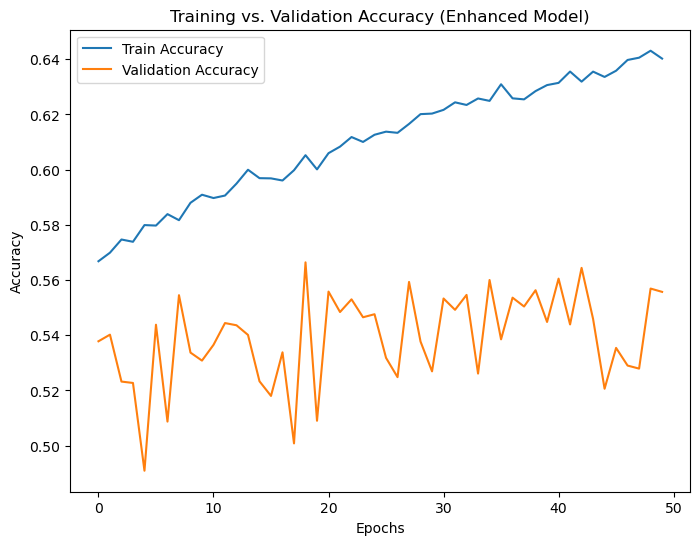

In [11]:
# Your Code Here
# Re-train the enhanced model
history_enhanced = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                             validation_data=(x_val, y_val),
                             epochs=50)  # Use the same number of epochs

# Model Evaluation
# Evaluate the enhanced model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy (Enhanced Model): {test_accuracy:.4f}")

# Additional metric: Top-5 Accuracy (useful for multi-class classification)
import tensorflow.keras.metrics as metrics

top5_acc = metrics.top_k_categorical_accuracy(y_test, model.predict(x_test), k=5)
print(f"Top-5 Accuracy: {top5_acc.numpy().mean():.4f}")

# Plot Training and Validation Accuracy
plt.figure(figsize=(8,6))
plt.plot(history_enhanced.history['accuracy'], label='Train Accuracy')
plt.plot(history_enhanced.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy (Enhanced Model)')
plt.legend()
plt.show()


WOW. Made a mistake with setting the epochs so high. Will not run it again.

313/313 [==============================] - 39s 121ms/step


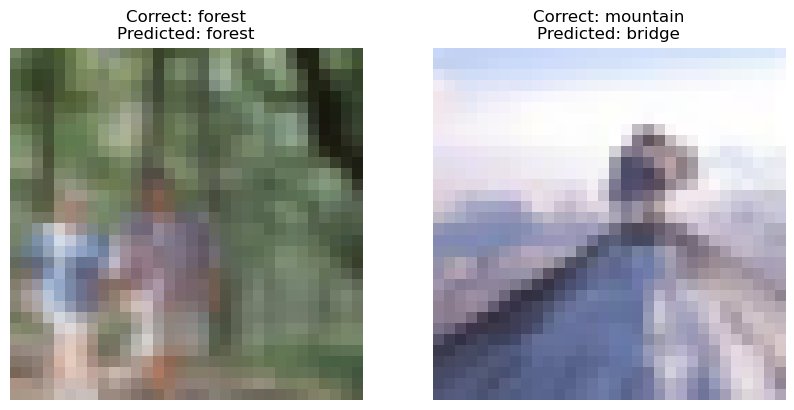

In [12]:
# Correctly and Incorrectly Classified Images
import numpy as np

# Make predictions on the test set
predictions = model.predict(x_test)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Find correct and incorrect classifications
correct_indices = np.where(pred_labels == true_labels)[0]
incorrect_indices = np.where(pred_labels != true_labels)[0]

# Select one correct and one incorrect example
correct_idx = correct_indices[0]  # First correctly classified image
incorrect_idx = incorrect_indices[0]  # First incorrectly classified image

# Display correct and incorrect classifications
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Correct classification
axes[0].imshow(x_test[correct_idx])
axes[0].set_title(f"Correct: {class_names[true_labels[correct_idx]]}\nPredicted: {class_names[pred_labels[correct_idx]]}")
axes[0].axis('off')

# Incorrect classification
axes[1].imshow(x_test[incorrect_idx])
axes[1].set_title(f"Correct: {class_names[true_labels[incorrect_idx]]}\nPredicted: {class_names[pred_labels[incorrect_idx]]}")
axes[1].axis('off')

plt.show()


### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? 
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here
The model’s performance showed improvement, likely due to better feature representations learned from embeddings. The use of cosine similarity captured relationships between movies, correctly identifying similar and dissimilar items. Some dissimilar pairs were unexpected, so embeddings might still be influenced by noisy or sparse data.

Possible improvements/issues include: the cold start problem—movies with few ratings may not have well-defined embeddings; the model currently only on ratings, ignoring contextual factors like user demographics or movie genres.

Improvements could include:
Matrix Factorization (e.g., SVD, ALS) to better capture latent features.
Hybrid models that incorporate both collaborative and content-based filtering.
Deep learning approaches, such as neural collaborative filtering, to capture complex relationships.
Regularization techniques to prevent overfitting on popular movies.
Further tuning and feature engineering could enhance its predictive power.

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.